In [33]:
# IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df=pd.read_csv(r"C:\Users\92331\Desktop\Customer Churn Prediction Model\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.shape

(7043, 21)

In [36]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
missing_values=(df['TotalCharges']==" ").sum()
df.replace(missing_values,np.nan,inplace=True)
df.isnull().sum()
df.dropna(inplace=True)

In [39]:
df['Churn'].value_counts()
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.531106
Yes    26.468894
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

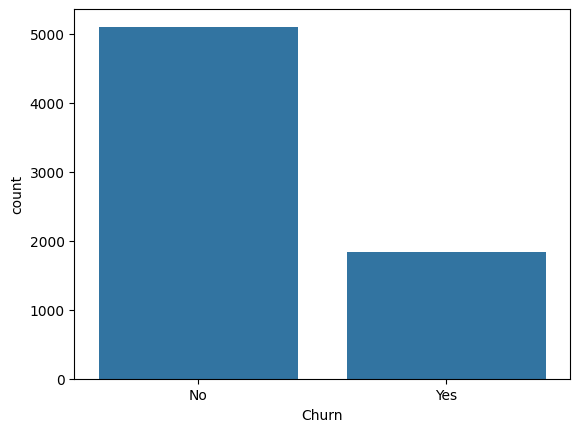

In [40]:
sns.countplot(x='Churn',data=df)

In [41]:
pd.to_numeric(df['tenure'],errors="coerce")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [42]:
numeric_columns=["MonthlyCharges","TotalCharges","tenure"]
df[numeric_columns].describe()

,MonthlyCharges,tenure
count,6944.000000,6944.000000
mean,64.851354,32.675835
std,30.120729,24.600069
min,18.250000,0.000000
25%,35.537500,9.000000
50%,70.400000,30.000000
75%,89.912500,56.000000
max,118.750000,72.000000


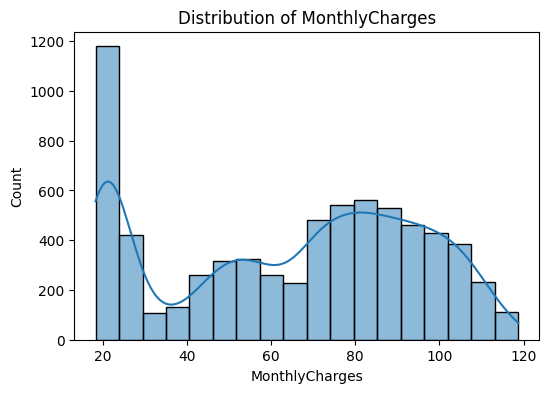

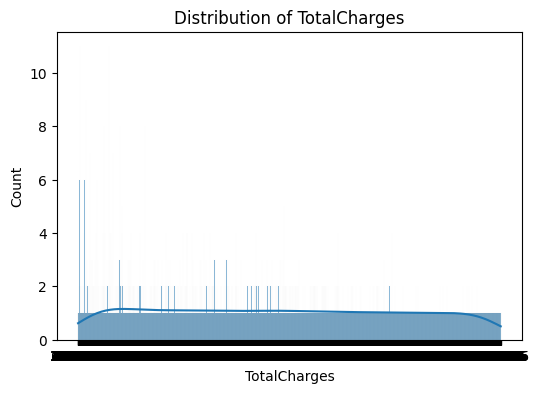

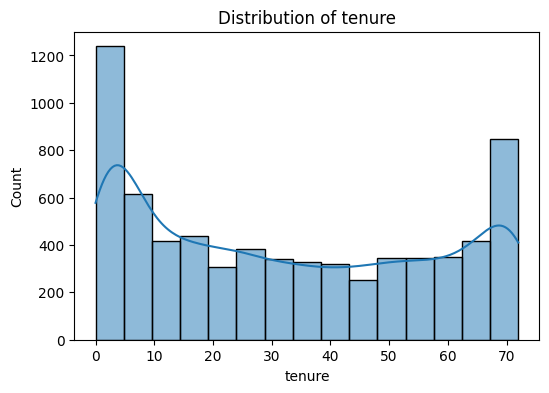

In [43]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


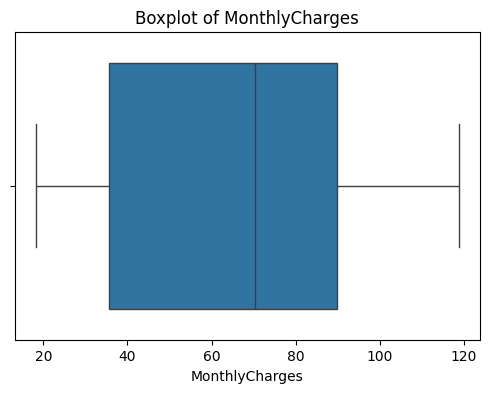

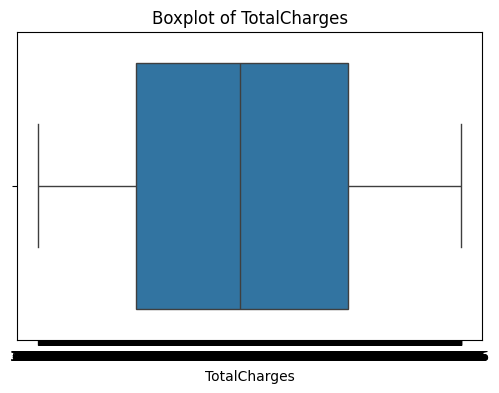

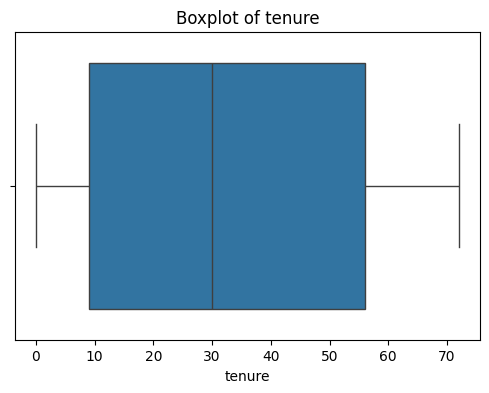

In [44]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


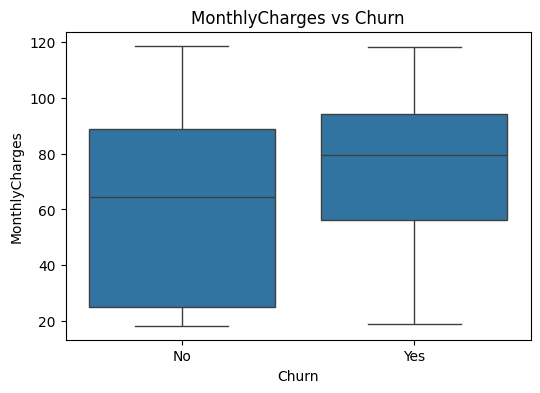

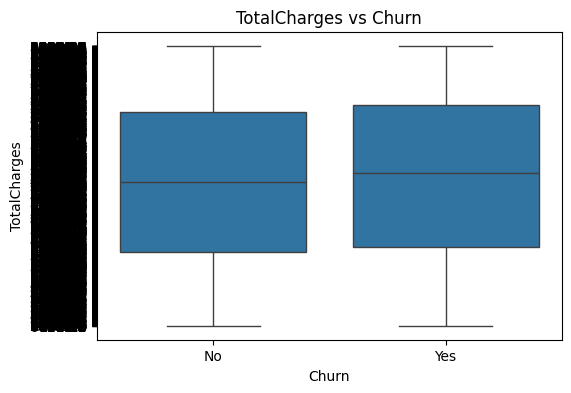

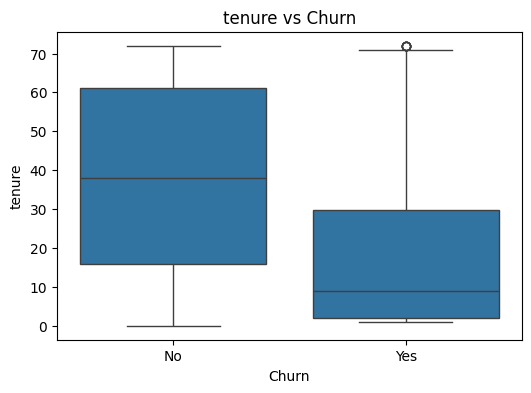

In [45]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()


In [46]:
df.drop(columns="customerID",inplace=True)
categorical_column = df.select_dtypes(include="object").columns
categorical_column
for col in categorical_column:
    print(col, df[col].nunique())

gender 2
Partner 2
Dependents 2
PhoneService 2
MultipleLines 3
InternetService 3
OnlineSecurity 3
OnlineBackup 3
DeviceProtection 3
TechSupport 3
StreamingTV 3
StreamingMovies 3
Contract 3
PaperlessBilling 2
PaymentMethod 4
TotalCharges 6448
Churn 2


In [47]:
#for cols in categorical_column:
    #plt.figure(figsize=(6,4))
    #sns.countplot(x=cols,hue="Churn",data=df)
   # plt.xticks(rotation=45)
    #plt.title(f"Churn by {col}")
    #plt.show()

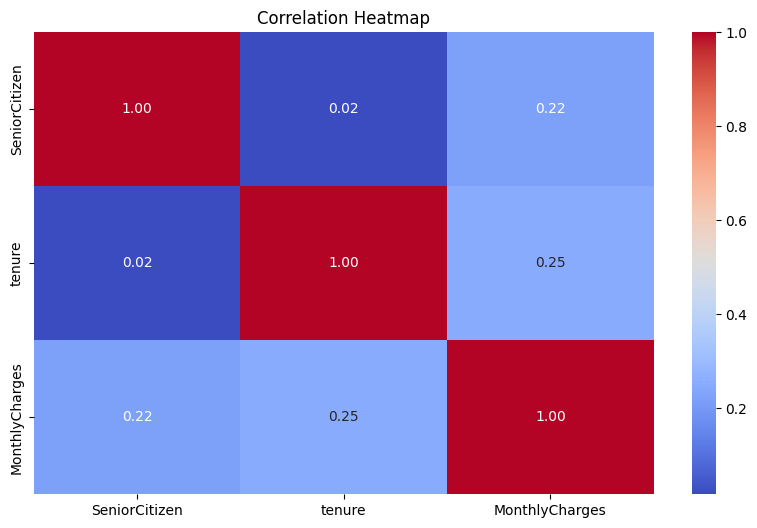

In [55]:
# 1. Automatically grab all numeric columns from your dataframe
numeric_df = df.select_dtypes(include=['number'])

# 2. Create the heatmap using the correlation matrix of those columns
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()


In [56]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100


Churn,No,Yes
Contract,,
Month-to-month,57.180501,42.819499
One year,88.690884,11.309116
Two year,97.159763,2.840237


CONCLUSION

summary of findings in EDA:-

1️⃣ Target Variable (Churn) Distribution

The dataset shows that customer churn is imbalanced, with a significantly larger number of customers staying compared to those who leave. This means:

Accuracy alone is not a reliable evaluation metric

Metrics like Recall, F1-score, and ROC-AUC will be more important during model evaluation

2️⃣ Customer Tenure

Customers who churn tend to have lower tenure, meaning they leave within the early months of joining.

Insight:
New customers are at a higher risk of churning. Retention strategies should focus on the first few months of subscription.

3️⃣ Monthly Charges

Customers with higher monthly charges show a greater tendency to churn.

Insight:
Pricing sensitivity may influence churn. Customers paying more may switch to competitors offering better deals.

4️⃣ Total Charges

Customers with low total charges are more likely to churn, which aligns with the observation that churned customers usually have shorter tenure.

Insight:
Long-term customers generate higher lifetime value and are less likely to leave.

5️⃣ Contract Type

Customers with month-to-month contracts have the highest churn rate, while customers with one-year or two-year contracts are much more stable.

Insight:
Long-term contracts significantly reduce churn risk. Encouraging customers to move to longer contracts could improve retention.

6️⃣ Internet Service Type

Customers using Fiber optic internet show higher churn compared to DSL users.

Possible Reason:
Fiber customers may have higher expectations for service quality and may churn if dissatisfied.

7️⃣ Payment Method

Customers using electronic checks tend to churn more than those using automatic payments (bank transfer or credit card).

Insight:
Automatic payment methods may indicate more committed customers.

8️⃣ Senior Citizens

Senior citizens show slightly different churn behavior compared to younger customers.

Insight:
Age-based service preferences may influence churn and could be explored further.